In [1]:
import os
PATH = "/home/dhayaa/DECADE/easyGalaxy/ezgal/data/"
os.environ['EZGAL_MODELS']  = f'{PATH}/models/'
os.environ['EZGAL_FILTERS'] = f'{PATH}/filters/'

In [3]:
import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

import matplotlib.pyplot as plt
plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=17)

/home/dhayaa/DECADE/easyGalaxy/ezgal/data//models/bc03_ssp_z_0.02_salp.model


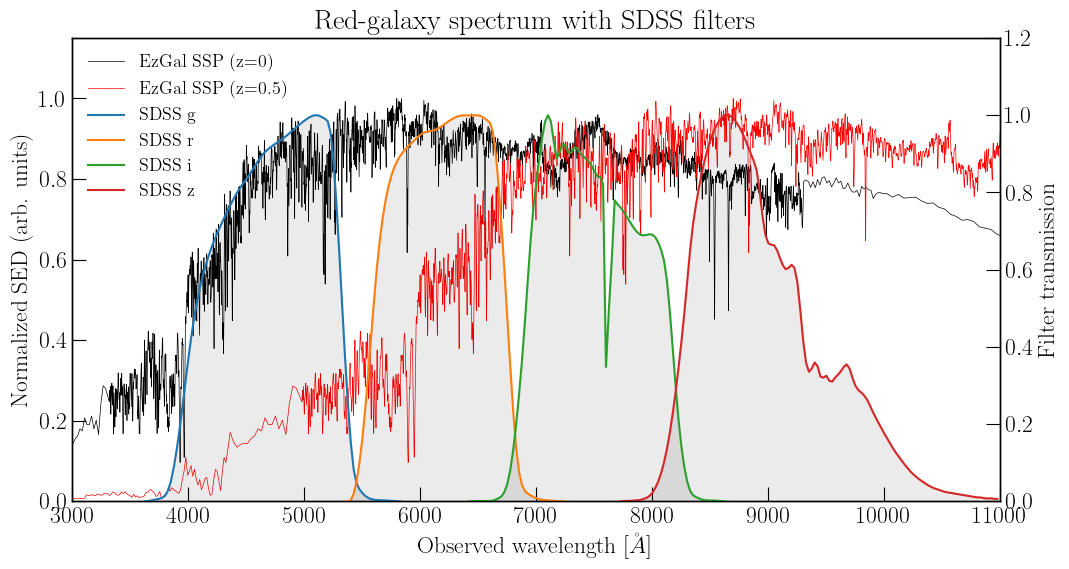

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import ezgal

# --------------------------------------------------
# Settings
# --------------------------------------------------
model_file = "bc03_ssp_z_0.02_salp.model"
zf = 3.0
zobs = 0.5

# --------------------------------------------------
# Load model and get spectrum
# --------------------------------------------------
model = ezgal.ezgal(model_file)

# EzGal wavelength grid (Angstrom)
wave = np.array(model.ls)

# Observed-frame SED at zobs for a population formed at zf
# Try Fv first since that is commonly supported
sed = np.array(model.get_sed_z(zf, zobs, units="Fv"))

# For display only, convert to something with a more familiar spectral shape
# F_lambda is proportional to F_nu / lambda^2
sed_plot = sed / wave**2
sed_plot /= np.nanmax(sed_plot)

# --------------------------------------------------
# Load built-in EzGal Sloan filters
# --------------------------------------------------
# These names are consistent with the EzGal examples/docs
filter_names = ["sloan_g", "sloan_r", "sloan_i", "sloan_z"]

# Depending on version, add_filter may populate the filter object into model.filters
for fname in filter_names:
    model.add_filter(fname)

# Grab wavelength / throughput arrays from the loaded filters
# Different EzGal installs sometimes expose these slightly differently,
# so we try a couple of common attribute names.
filter_curves = []

for fname in filter_names:
    filt = model.filters[fname]

    fw = np.array(filt.ls)
    ft = np.array(filt.tran_ls)

    filter_curves.append((fname, fw, ft))

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(11, 6))

# Spectrum
ax1.plot(wave, sed_plot, lw=0.5, color="black",
         label=f"EzGal SSP (z=0)")

# Observed 4000 A break
ax1.plot(wave  * (1.0 + zobs), sed_plot, lw=0.5, color="r", label=f"EzGal SSP (z={zobs})")


ax1.set_xlabel(r"Observed wavelength [$\AA$]")
ax1.set_ylabel(r"Normalized SED (arb. units)")
ax1.set_xlim(3000, 11000)
ax1.set_ylim(0, 1.15)

# Filters on twin axis
ax2 = ax1.twinx()
ax2.set_ylabel("Filter transmission")
ax2.set_ylim(0, 1.2)

pretty = {
    "sloan_g": "SDSS g",
    "sloan_r": "SDSS r",
    "sloan_i": "SDSS i",
    "sloan_z": "SDSS z",
}

for fname, fw, ft in filter_curves:
    m = (fw >= 3000) & (fw <= 11000)
    ax2.fill_between(fw[m], 0, ft[m] / np.max(ft[m]), alpha=0.08, color = 'k')
    ax2.plot(fw[m], ft[m] / np.max(ft[m]), lw=1.5, label=pretty[fname], )

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=13)

plt.title("Red-galaxy spectrum with SDSS filters")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Color')

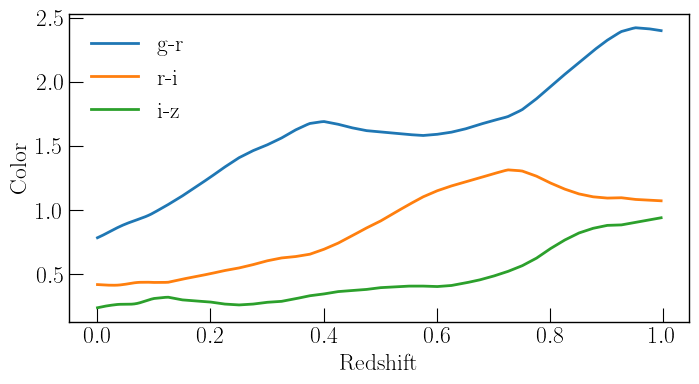

In [12]:
import fitsio
X = fitsio.read('/home/dhayaa/Roman/RedmapperRoman/calibdata/initcolors/bc03_colors_lsst.fit')

plt.figure(figsize = (8,4))

bands = 'ugriz'

m = X['Z'] < 1
for i in range(1, 4):
    plt.plot(X['Z'][m], X['COLOR'][m, i], label = f'{bands[i]}-{bands[i + 1]}', lw = 2)
    
plt.legend()
plt.xlabel('Redshift')
plt.ylabel('Color')